In [69]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

# Sesión 10 Laboratorio de Computación Cuántica 2

## Introducción a la Quantum Error Correction

Ya vimos que las computadoras tipicas constantemente tienen errores. En esta sesión visualizaremos una introducción al area de corrección de errores cuánticos para que entendamos como podemos lidiar con el efecto de diversos canales cuánticos sobre el sistema

### El Qubit Lógico

La idea detras de los algoritmos cuánticos de corrección de errores indica que los estados, en lugar de guardarse dentro de un qubit físico como se ha hecho hasta ahora, los cuales son suceptibles a diversos canales de error, se fabrica una nueva entidad, el Qubit Lógico, el cual es un qubit que esta conformado por varios qubits físicos que trabajan con ayuda constante de protocolos de corrección de errores}

$$|\psi\rangle=\alpha|0_L\rangle+\beta|1_L\rangle$$

### Recordatorio: bit-flip

El error más sencillo es el bit-flip:

$$
X|0\rangle = |1\rangle, \qquad X|1\rangle = |0\rangle
$$

Si el qubit almacena

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
$$

entonces un bit-flip produce

$$
X|\psi\rangle = \alpha|1\rangle + \beta|0\rangle.
$$

### El problema de la corrección clásica de errores

En computación clásica:

$$
0 \rightarrow 000, \quad 1 \rightarrow 111
$$

Pero en cuántica:

$$
|\psi\rangle \not\rightarrow |\psi\rangle|\psi\rangle|\psi\rangle
$$

Esto se debe al **teorema de no clonación**.

Entonces necesitamos otra estrategia.

### Código de 3 qubits (bit-flip)

Definimos:

$$
|0\rangle \rightarrow |000\rangle
$$

$$
|1\rangle \rightarrow |111\rangle
$$

Entonces:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

se codifica como:

$$
|\psi_L\rangle = \alpha|000\rangle + \beta|111\rangle
$$

(Para lograr esto, basta simplemente con aplicar CNOTS entre el primer qubit y otros 2 qubits iniciados en estado 0)

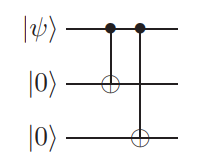

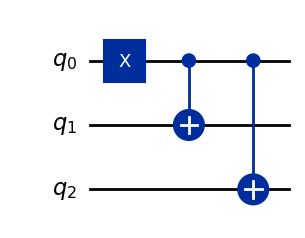

In [70]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(3)


qc.x(0) #Edo inicial |1>


qc.cx(0, 1) #CNOTS
qc.cx(0, 2)

qc.draw("mpl")

En este sistema, nuestro qubit lógico esta codificado en 3 qubits físicos que nos permiten visualizar el sistema. De modo que $\alpha |0_L\rangle + \beta|1_L\rangle=\alpha |000\rangle + \beta|111\rangle$ (En este caso, el estado es solo $|1_L\rangle$)

Ahora, introduzcamos un error de bit flip al sistema, para ello, hagamos una simulación con una compuerta Paulli-x

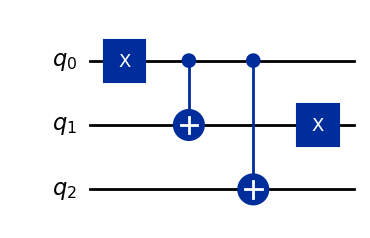

In [71]:
qc_error = qc.copy()  # Copiamos el circuito, usa este codigo cuando lo consideres util

qc_error.x(1) # Error en qubit 1

qc_error.draw("mpl")

Ahora, veamos que pasa si no realizamos corrección de errores:

In [72]:
qc_no_corr = qc_error.copy()
qc_no_corr.measure_all()

backend = AerSimulator(method="statevector")
compiled = transpile(qc_no_corr, backend)
result = backend.run(compiled, shots=1024).result()

counts_no = result.get_counts()
counts_no

{'101': 1024}

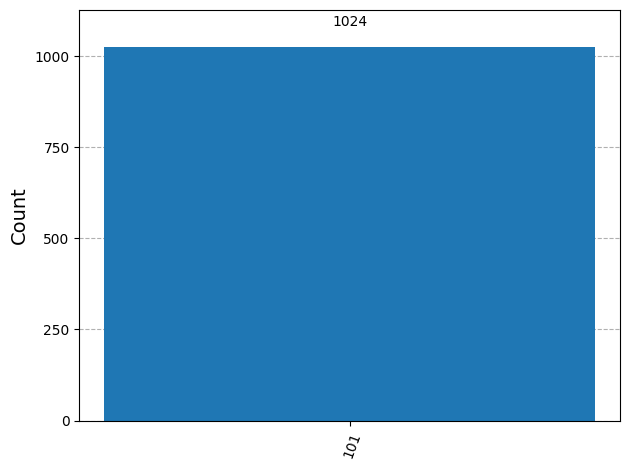

In [73]:
plot_histogram(counts_no)

Recuperamos no el estado que buscamos, si no un estado de superposición. Esto es problematico, pero tras hacer mediciones, es facil de entender que hacer. El problema, aqui tenemos un estado determinado y ya medimos, pero nosotros no queremos perder por lo general el estado cuántico que ya hemos codificado. Esto requiere un analisis mas complejo

### Detección de errores (síndrome)

No medimos el estado directamente.

Medimos relaciones entre qubits aplicando los CNOTS. Para ello, colocamos 2 qubits Ancilla, que nos van a codificar si todo esta en orden y el resultado de medirlos nos dira si funciona correctamente o no

Esto nos permite identificar qué qubit falló sin destruir la información cuántica. Para ello, estudiamos la paridad de los qubits con los que trabajamos. Si los qubits cambian (que no deberian), los ancillas nos mediran 1, lo cual permite detectar donde y cuando hay error

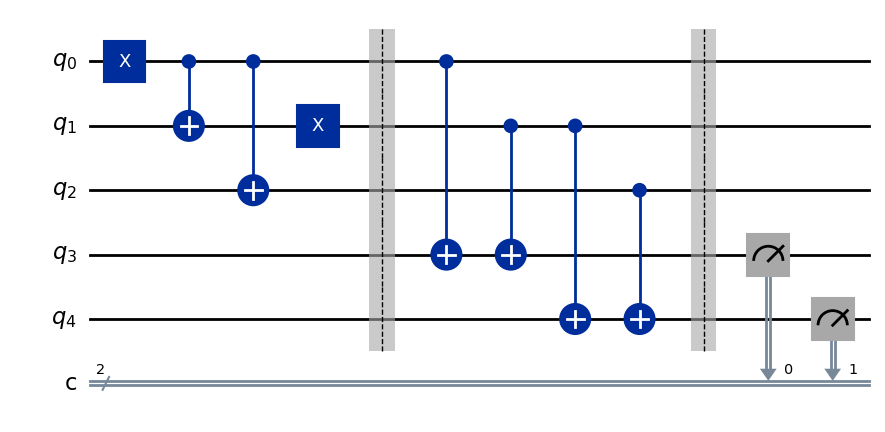

In [74]:
qc_syndrome = QuantumCircuit(5, 2)

qc_syndrome.x(0) #Edo inicial |1> en el qubit 0

qc_syndrome.cx(0, 1)
qc_syndrome.cx(0, 2)

qc_syndrome.x(1) #Simulamos el error en el qubit 1

qc_syndrome.barrier()

# Síndrome 1 (q0 vs q1)
qc_syndrome.cx(0, 3)
qc_syndrome.cx(1, 3)

# Síndrome 2 (q1 vs q2)
qc_syndrome.cx(1, 4)
qc_syndrome.cx(2, 4)
qc_syndrome.barrier()

# Medimos ancillas
qc_syndrome.measure(3, 0)
qc_syndrome.measure(4, 1)

qc_syndrome.draw("mpl")

Fijate como $q_3$ tiene la paridad de $q_0$ y $q_1$, mientras qur $q_4$ tiene la paridad de $q_1$ y $q_2$. Si ocurre un bitflip, el cambio en la paridad se detecta como un 1 en los sistemas

In [75]:
compiled = transpile(qc_syndrome, backend)
result = backend.run(compiled, shots=1024).result()

counts_syndrome = result.get_counts()
counts_syndrome

{'11': 1024}

### Interpretación del síndrome

| Síndrome | Error |
|--------|------|
| 00 | No error |
| 10 | Error en q0 |
| 11 | Error en q1 |
| 01 | Error en q2 |

El síndrome nos dice dónde ocurrió el error, no el estado. En función de la medida del sindrome, podemos aplicar corrección de errores para mitigar el error del sistema sin destruir el estado midiendo

### Limitación del código de 3 qubits, recordatorio del phase flip

Hasta ahora corregimos errores de tipo bit-flip:

$$
X|0\rangle = |1\rangle, \qquad X|1\rangle = |0\rangle
$$

Pero existen otros errores.

Uno de los más importantes es el **phase-flip**, producido por la compuerta $Z$:

$$
Z|0\rangle = |0\rangle
$$

$$
Z|1\rangle = -|1\rangle
$$

Este error no cambia el bit. Cambia la fase relativa.

## ¿Qué hace un phase flip?

Si tenemos un estado:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

un error de fase produce:

$$
Z|\psi\rangle = \alpha|0\rangle - \beta|1\rangle
$$



### Código de 3 qubits contra phase-flip

Para corregir errores de fase, usamos la misma idea del código anterior, pero en otra base.

Antes:

$$
|0_L\rangle = |000\rangle
$$

$$
|1_L\rangle = |111\rangle
$$

Ahora:

$$
|0_L\rangle = |+++\rangle
$$

$$
|1_L\rangle = |---\rangle
$$

La clave, es lograr re-interpretar el Phase-flip como un bit flip con Hadamards y resolver el sistema como tal

La lógica sigue siendo la misma:

- Estado correcto → los tres qubits coinciden
- Error → uno de los qubits deja de coincidir

La diferencia es que ahora la comparación ocurre en otra base.


## ¿Cómo comparamos en la base Hadamard?

En el código anterior comparábamos directamente los qubits usando CNOTs.

Eso funcionaba porque estábamos trabajando en la base computacional:

$$
|0\rangle,\ |1\rangle
$$

Pero ahora los estados importantes son:

$$
|+\rangle,\ |-\rangle
$$

Entonces necesitamos cambiar temporalmente de base.

Usamos la compuerta Hadamard:

$$
H|+\rangle = |0\rangle
$$

$$
H|-\rangle = |1\rangle
$$

Esto significa que:

- En la base Hadamard, un error de fase se comporta como un error de bit
- Podemos reutilizar exactamente la misma lógica del código anterior

La estrategia es:

1. Aplicar Hadamard a todos los qubits
2. Convertir el problema de phase-flip en un problema de bit-flip
3. Comparar qubits usando CNOTs
4. Detectar inconsistencias
5. Aplicar Hadamard nuevamente




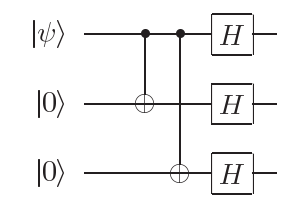

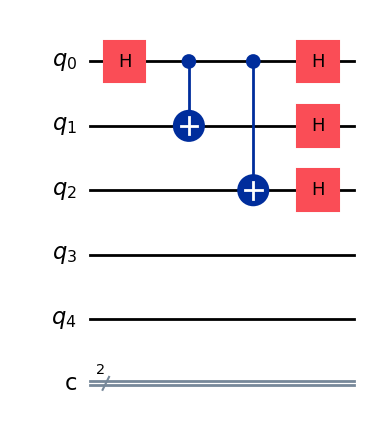

In [76]:
qc_phase = QuantumCircuit(5, 2)

qc_phase.h(0)  #Estamos en la base Hadamard, por lo que el estado inicial es |+>

qc_phase.cx(0,1) #Encodamos la información de fase en los qubits 1 y 2
qc_phase.cx(0,2)

# Cambiamos todos a base Hadamard
qc_phase.h(0)
qc_phase.h(1)
qc_phase.h(2)

qc_phase.draw("mpl")

Después de aplicar Hadamard a todos los qubits:

$$|+\rangle \rightarrow |0\rangle$$

$$|-\rangle \rightarrow |1\rangle$$

Ahora los errores de fase se comportan como errores de bit.

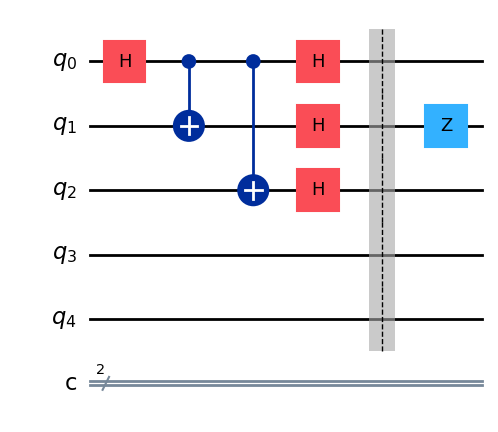

In [77]:
qc_phase.barrier()
qc_phase.z(1)

qc_phase.draw("mpl")

El error Z altera la fase del segundo qubit.

Pero después del cambio de base con Hadamard, esto se verá como una inconsistencia tipo bit-flip.

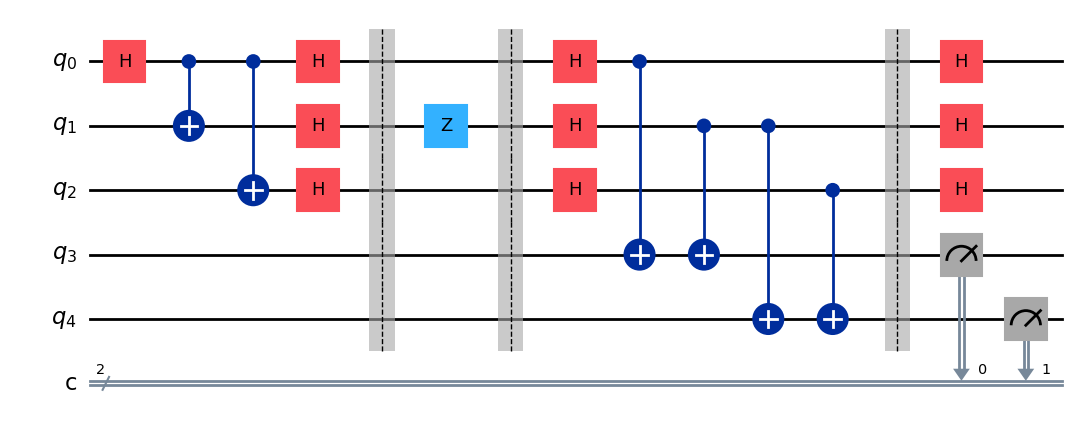

In [78]:
qc_phase.barrier()

qc_phase.h(0)
qc_phase.h(1)
qc_phase.h(2)

qc_phase.cx(0,3)
qc_phase.cx(1,3)


qc_phase.cx(1,4)
qc_phase.cx(2,4)


qc_phase.barrier()

qc_phase.h(0)
qc_phase.h(1)
qc_phase.h(2)


qc_phase.measure(3,0)
qc_phase.measure(4,1)


qc_phase.draw("mpl")

In [79]:
compiled = transpile(qc_phase, backend)
result = backend.run(compiled, shots=1024).result()

counts_phase = result.get_counts()
counts_phase

{'11': 1024}

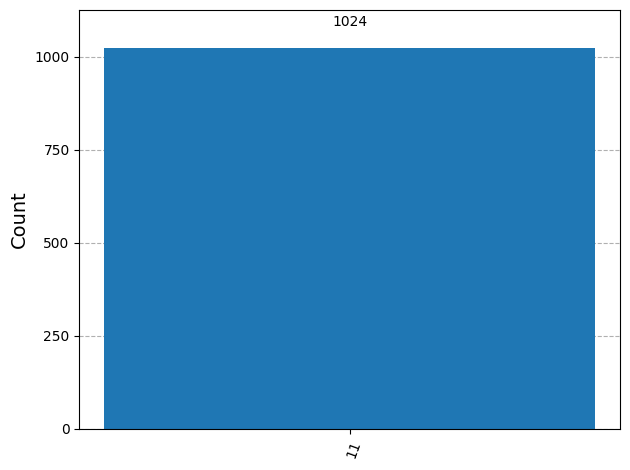

In [80]:
plot_histogram(counts_phase)

### Código de Shor

Hasta ahora, ya vimos dos códigos fundamentales:

- El código de repetición de 3 qubits para corregir errores de bit flip ($X$)
- El código de repetición en la base Hadamard para corregir errores de phase flip ($Z$)

Sin embargo, un sistema cuántico real puede sufrir ambos tipos de errores simultáneamente.  
El objetivo del código de Shor es construir un esquema capaz de corregir:

$$
X,\quad Z,\quad Y=iXZ
$$

sobre cualquier qubit físico.


### Idea principal del código de Shor

El código de Shor combina ambos métodos anteriores:

1. Primero protege contra errores de fase
2. Después protege contra errores de bit

La idea central es jerárquica:

- usar redundancia en la base Hadamard para proteger la fase,
- y después usar redundancia clásica para proteger cada qubit físico contra bit flips.

Esto produce un código de:

$$
1 \text{ qubit lógico } \to 9 \text{ qubits físicos}
$$

# Estados lógicos

El código define los estados lógicos:

$$
|0_L\rangle =
\frac{
(|000\rangle + |111\rangle)
}{\sqrt 2}
\otimes
\frac{
(|000\rangle + |111\rangle)
}{\sqrt 2}
\otimes
\frac{
(|000\rangle + |111\rangle)
}{\sqrt 2}
$$

$$
|1_L\rangle =
\frac{
(|000\rangle - |111\rangle)
}{\sqrt 2}
\otimes
\frac{
(|000\rangle - |111\rangle)
}{\sqrt 2}
\otimes
\frac{
(|000\rangle - |111\rangle)
}{\sqrt 2}
$$

Por lo tanto, un qubit arbitrario:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

queda codificado como:

$$
|\psi_L\rangle =
\alpha |0_L\rangle + \beta |1_L\rangle
$$


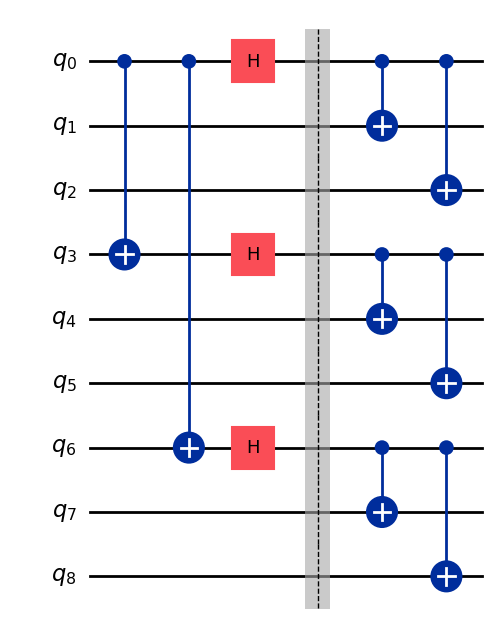

In [81]:
qc = QuantumCircuit(9)


qc.cx(0, 3)
qc.cx(0, 6)

qc.h(0)
qc.h(3)
qc.h(6)

qc.barrier()

# Bloque 1
qc.cx(0, 1)
qc.cx(0, 2)

# Bloque 2
qc.cx(3, 4)
qc.cx(3, 5)

# Bloque 3
qc.cx(6, 7)
qc.cx(6, 8)

# Dibujar circuito
qc.draw('mpl')

Veamos como aplicar esto para una corrección de bit flip. Usaremos el mismo código que ya usamos antes para visualizarlo pero con registros cuanticos y ancillas extra para poder verlo

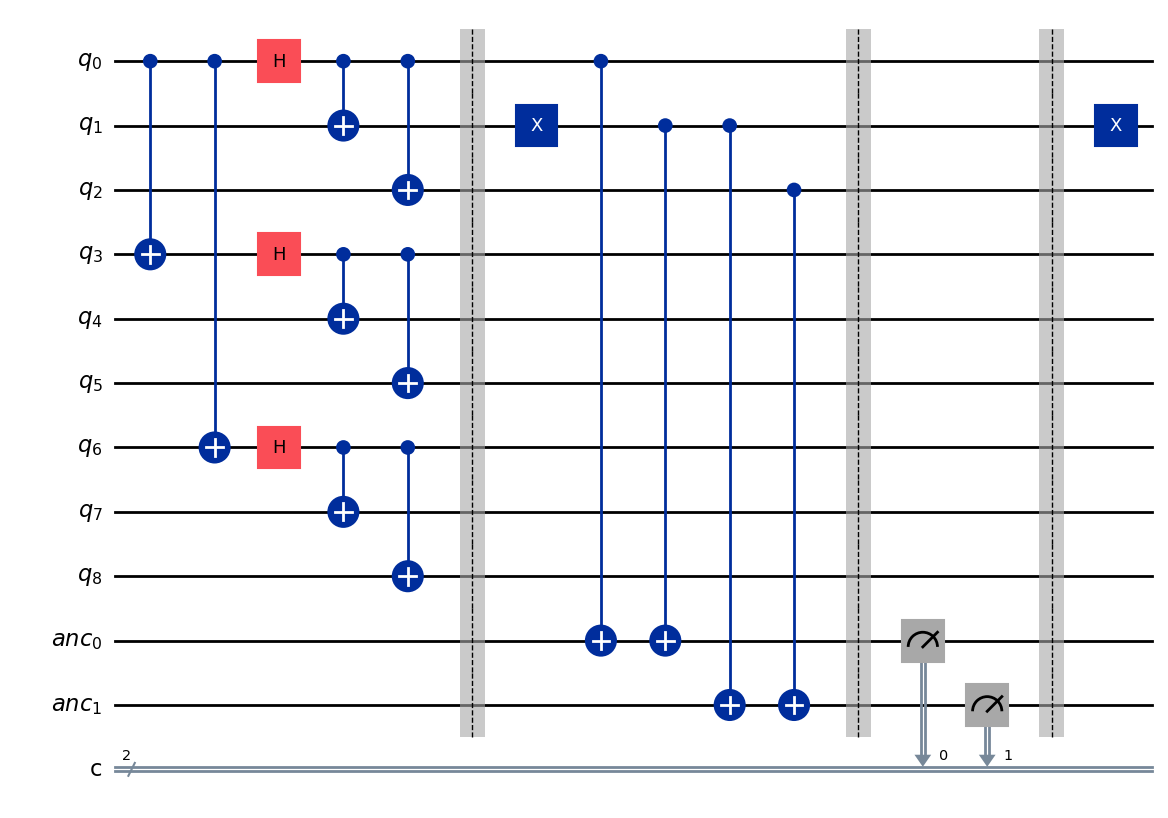

In [82]:
q = QuantumRegister(9, 'q')
anc = QuantumRegister(2, 'anc')
c = ClassicalRegister(2, 'c')

qc = QuantumCircuit(q, anc, c) # 3 registros: 9 qubits físicos, 2 ancillas, 2 bits clásicos


qc.cx(q[0], q[3])
qc.cx(q[0], q[6])

qc.h(q[0])
qc.h(q[3])
qc.h(q[6])

# Bloque 1
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])

# Bloque 2
qc.cx(q[3], q[4])
qc.cx(q[3], q[5])

# Bloque 3
qc.cx(q[6], q[7])
qc.cx(q[6], q[8])

qc.barrier()

qc.x(q[1]) # Simulamos un error de bit flip en el qubit 1

# Repetimos el sindrome del bit flip en el bloque 1 para detectar el error

qc.cx(q[0], anc[0])
qc.cx(q[1], anc[0])

qc.cx(q[1], anc[1])
qc.cx(q[2], anc[1])

qc.barrier()

qc.measure(anc, c)

qc.barrier()

qc.x(q[1])

qc.draw('mpl')

In [83]:
backend = AerSimulator()

transpiled_qc = transpile(qc, backend)

result = backend.run(transpiled_qc, shots=1024).result()

counts = result.get_counts()

print(counts)

{'11': 1024}


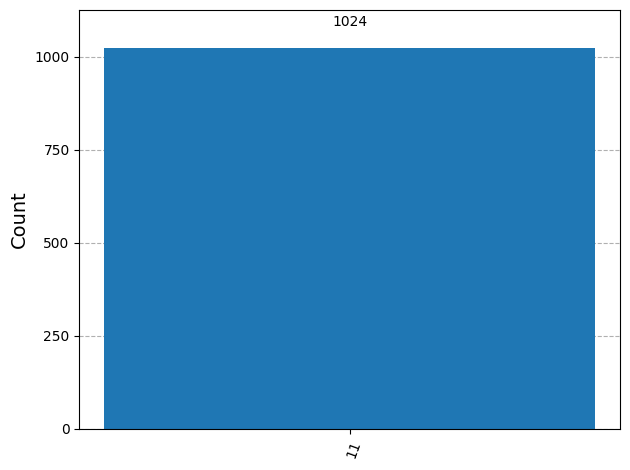

In [84]:
plot_histogram(counts)

Ahora, haremos lo mismo con el Phase Flip

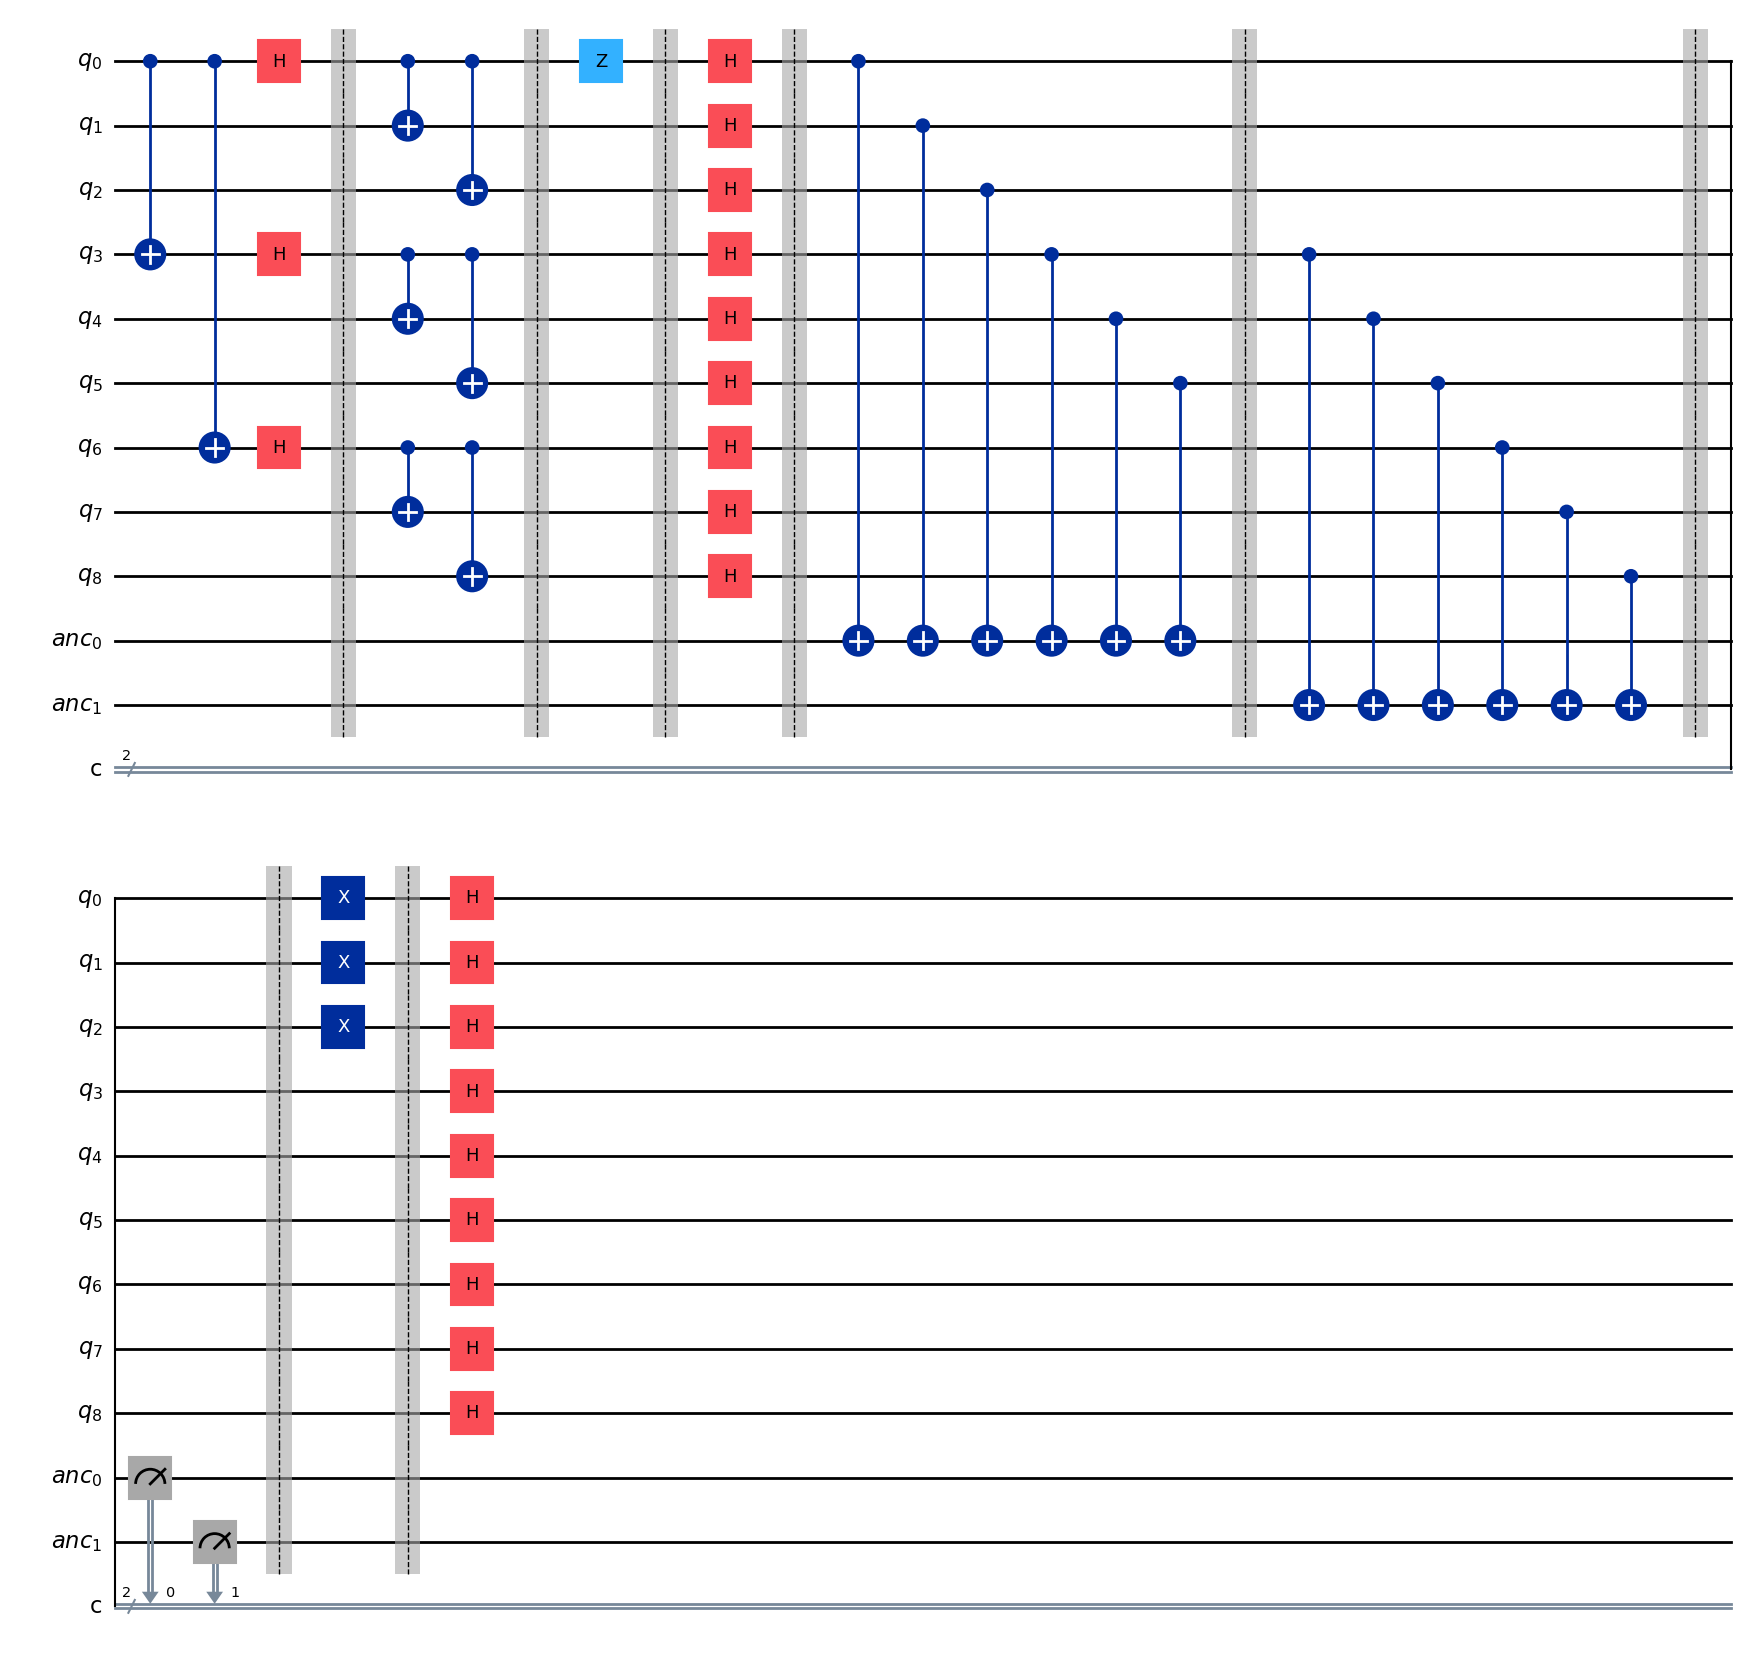

In [ ]:
q = QuantumRegister(9, 'q')
anc = QuantumRegister(2, 'anc')
c = ClassicalRegister(2, 'c')

qc = QuantumCircuit(q, anc, c)


qc.cx(q[0], q[3])
qc.cx(q[0], q[6])

qc.h(q[0])
qc.h(q[3])
qc.h(q[6])

qc.barrier()

# Bloque 1
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])

# Bloque 2
qc.cx(q[3], q[4])
qc.cx(q[3], q[5])

# Bloque 3
qc.cx(q[6], q[7])
qc.cx(q[6], q[8])

qc.barrier()

qc.z(q[0]) #Simulamos un error de phase flip en el qubit 0

qc.barrier()

qc.h(range(9)) #Pasamos a base Hadamard para detectar el error de phase flip

qc.barrier()

#Aqui comparamos el bloque 1 con el bloque 2, y el bloque 2 con el bloque 3 para detectar el error de phase flip

for i in range(3):
    qc.cx(q[i], anc[0])

for i in range(3,6):
    qc.cx(q[i], anc[0])

qc.barrier()

for i in range(3,6):
    qc.cx(q[i], anc[1])

for i in range(6,9):
    qc.cx(q[i], anc[1])

qc.barrier()

qc.measure(anc, c)

qc.barrier()

#Una vez detectado el error, aplicamos la corrección correspondiente (Esta corrección es para el error de phase flip en el qubit 0, si el error estuviera en otro qubit, la corrección sería diferente)


qc.x(q[0])
qc.x(q[1])
qc.x(q[2])

qc.barrier()

qc.h(range(9))

qc.draw('mpl')

{'01': 1024}


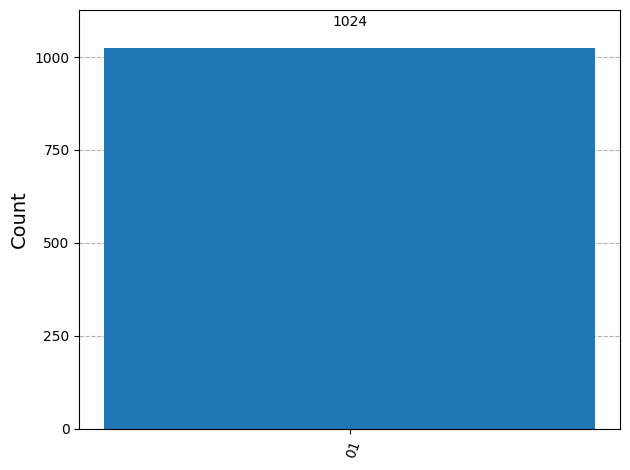

In [86]:

backend = AerSimulator()

transpiled_qc = transpile(qc, backend)

result = backend.run(transpiled_qc, shots=1024).result()

counts = result.get_counts()

print(counts)


plot_histogram(counts)
